In [127]:
# libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import tensorflow as tf
import copy
import kagglehub
import os
from keras.models import Sequential
from keras.layers import Dense
from keras import callbacks
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

> In this notebook we create a neural network and train it on our dataset(global-coffee-health-dataset), first for a binary classification task and then for a regression one. After that we change some parameters and analyse the results. 

## Preprocessing Dataset

> Our dataset is global-coffee-health-dataset, which consists of some columns related to sleep quality, heart rate, stress level, amount of coffee intake, ... . We use this dataset for 2 tasks, the first is binary classification, we aim to predict the sleep quality (poor, excellent), based on the data, note that the sleep quality column has actually 4 classes (poor, fair, good, excellent), but first because the data is imbalanced and second because we want binary classification, we extracted only the rows that their sleep quality column is poor or excellent.

>Second is the regression task, we aim to determine the sleep hours based on the data.

In [215]:
# Load dataset
dataset_path = kagglehub.dataset_download("uom190346a/global-coffee-health-dataset")

print("Files in dataset:", os.listdir(dataset_path))

csv_file_path = os.path.join(dataset_path, 'synthetic_coffee_health_10000.csv')
df = pd.read_csv(csv_file_path)

print(df.shape)
df.head()

Using Colab cache for faster access to the 'global-coffee-health-dataset' dataset.
Files in dataset: ['synthetic_coffee_health_10000.csv']
(10000, 16)


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [13]:
df.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


In [216]:
df.drop(['Health_Issues'], axis=1, inplace=True)
print(df.isnull().sum())

ID                         0
Age                        0
Gender                     0
Country                    0
Coffee_Intake              0
Caffeine_mg                0
Sleep_Hours                0
Sleep_Quality              0
BMI                        0
Heart_Rate                 0
Stress_Level               0
Physical_Activity_Hours    0
Occupation                 0
Smoking                    0
Alcohol_Consumption        0
dtype: int64


In [15]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [217]:
# check for non-numerical columns

non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()
print("Non-numerical columns:", non_numeric_cols)

Non-numerical columns: ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation']


In [218]:
# encoding
df['Country'] = df['Country'].astype('category').cat.codes
df['Occupation'] = df['Occupation'].astype('category').cat.codes

In [219]:
df['Stress_Level'] = df['Stress_Level'].map({'Low':0, 'Medium':1, 'High':2})
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1, 'Other':2})
df['Sleep_Quality'] = df['Sleep_Quality'].map({'Poor':0, 'Fair':2, 'Good':3, 'Excellent':1}) # As we want to extract only poor and excellent, we set their codes to 0 and 1

In [164]:
df.head(5)

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Occupation,Smoking,Alcohol_Consumption
0,1,40,0,7,3.5,328.1,7.5,3,24.9,78,0,14.5,2,0,0
1,2,33,0,7,1.0,94.1,6.2,3,20.0,67,0,11.0,3,0,0
2,3,42,0,2,5.3,503.7,5.9,2,22.7,59,1,11.2,1,0,0
3,4,53,0,7,2.6,249.2,7.3,3,24.7,71,0,6.6,2,0,0
4,5,32,1,15,3.1,298.0,5.3,2,24.1,76,1,8.5,4,0,1


In [ ]:
sns.pairplot(df, diag_kind = 'hist',hue='Stress_Level',
             plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'}, size = 4)

Text(0.5, 1.0, 'Sleep Quality Distribution')

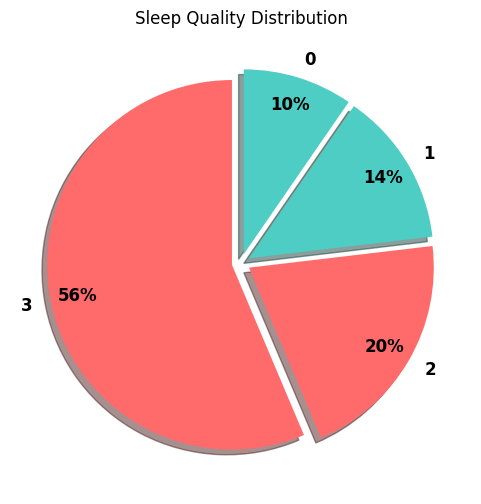

In [220]:
# data visualization
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

# colors
colors = ['#FF6B6B', '#FF6B6B', '#4ECDC4', '#4ECDC4']

# create pie chart
pie_data = df['Sleep_Quality'].value_counts()


wedges, texts, autotexts = ax.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.0f%%',
    radius=1,
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    pctdistance=0.85,
    labeldistance=1.1
)
ax.set_title('Sleep Quality Distribution')


## Binary Classification

In [221]:
# Extract poor and excellent quality
df_filtered = df[(df['Sleep_Quality'] == 0) | (df['Sleep_Quality'] == 1)]       # For binary classification

In [222]:
df_filtered.shape

(2313, 15)

In [223]:
df_classification = df_filtered.copy()

In [224]:
target_variable = df_classification.pop('Sleep_Quality')

In [225]:
# Normalization
scaler = MinMaxScaler()

standard_scaling_columns = list(df.columns)
df[standard_scaling_columns] = scaler.fit_transform(df[standard_scaling_columns])
df[standard_scaling_columns].describe()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Occupation,Smoking,Alcohol_Consumption
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000
mean,0.500000,0.273373,0.272650,0.498253,0.306004,0.305538,0.519460,0.745433,0.387365,0.349454,0.19860,0.499136,0.497300,0.20040,0.300700
std,0.288718,0.180015,0.270729,0.302110,0.176859,0.176533,0.174579,0.337896,0.168380,0.166491,0.32851,0.287679,0.351415,0.40032,0.458585
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000
25%,0.250000,0.129032,0.000000,0.210526,0.182927,0.177816,0.400000,0.666667,0.271552,0.237288,0.00000,0.246667,0.250000,0.00000,0.000000
50%,0.500000,0.258065,0.500000,0.473684,0.304878,0.301679,0.514286,1.000000,0.387931,0.355932,0.00000,0.500000,0.500000,0.00000,0.000000
75%,0.750000,0.403226,0.500000,0.736842,0.426829,0.425509,0.642857,1.000000,0.500000,0.457627,0.50000,0.746667,0.750000,0.00000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000


In [226]:
y = target_variable

In [227]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df_classification, y, test_size=0.3)
print(X_train.shape)
print(X_test.shape)

(1619, 14)
(694, 14)


In [228]:
# Create model
model = Sequential()

# Add a layer with 30 hidden neurons
model.add(Dense(30, input_dim=X_train.shape[1], activation='sigmoid'))

# Add a layer with 10 hidden neurons
model.add(Dense(10, activation='relu'))

# Add a layer with 2 hidden neurons
model.add(Dense(3, activation='tanh'))

# Add the output layer, with sigmoid activation fuction (to predict the rain)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [229]:
# early stopping
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,          # minimium amount of change to be considered an improvement
    patience=20,              # number of epochs to wait before deciding there is no significant improvement in training
    restore_best_weights=True,
)

In [230]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall()],
    )

In [231]:
history = model.fit(X_train, y_train,
                    batch_size = 16,
                    epochs = 100,
                    validation_split=0.2,
                    callbacks=[early_stopping]
                    )

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.7451 - precision_8: 0.5826 - recall_8: 0.9338 - val_loss: 0.6641 - val_precision_8: 0.6052 - val_recall_8: 0.8586
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6689 - precision_8: 0.5909 - recall_8: 0.8608 - val_loss: 0.6647 - val_precision_8: 0.6221 - val_recall_8: 0.8534
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6621 - precision_8: 0.5954 - recall_8: 0.8432 - val_loss: 0.6729 - val_precision_8: 0.6832 - val_recall_8: 0.5759
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6658 - precision_8: 0.6081 - recall_8: 0.7527 - val_loss: 0.6646 - val_precision_8: 0.5816 - val_recall_8: 0.8953
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6669 - precision_8: 0.5889 - recall_8: 0.9176 - val_loss: 0.6700 - val_precision_8: 0.7111 - val_recall_8: 0.3351
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6595 - precision_8: 0.6080 - recall_8: 0.7230 - val_loss: 0.660

In [232]:
predictions = model.predict(X_test)
print('Macro F1-score is %.2f' %f1_score(y_test, predictions>0.4, average='macro'))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Macro F1-score is 0.74


In [233]:
hist_df = pd.DataFrame(history.history)
hist_df.head()

,loss,precision_8,recall_8,val_loss,val_precision_8,val_recall_8
0,0.745098,0.582631,0.933784,0.664090,0.605166,0.858639
1,0.668858,0.590909,0.860811,0.664702,0.622137,0.853403
2,0.662079,0.595420,0.843243,0.672895,0.683230,0.575916
3,0.665785,0.608079,0.752703,0.664621,0.581633,0.895288
4,0.666897,0.588899,0.917568,0.669991,0.711111,0.335079


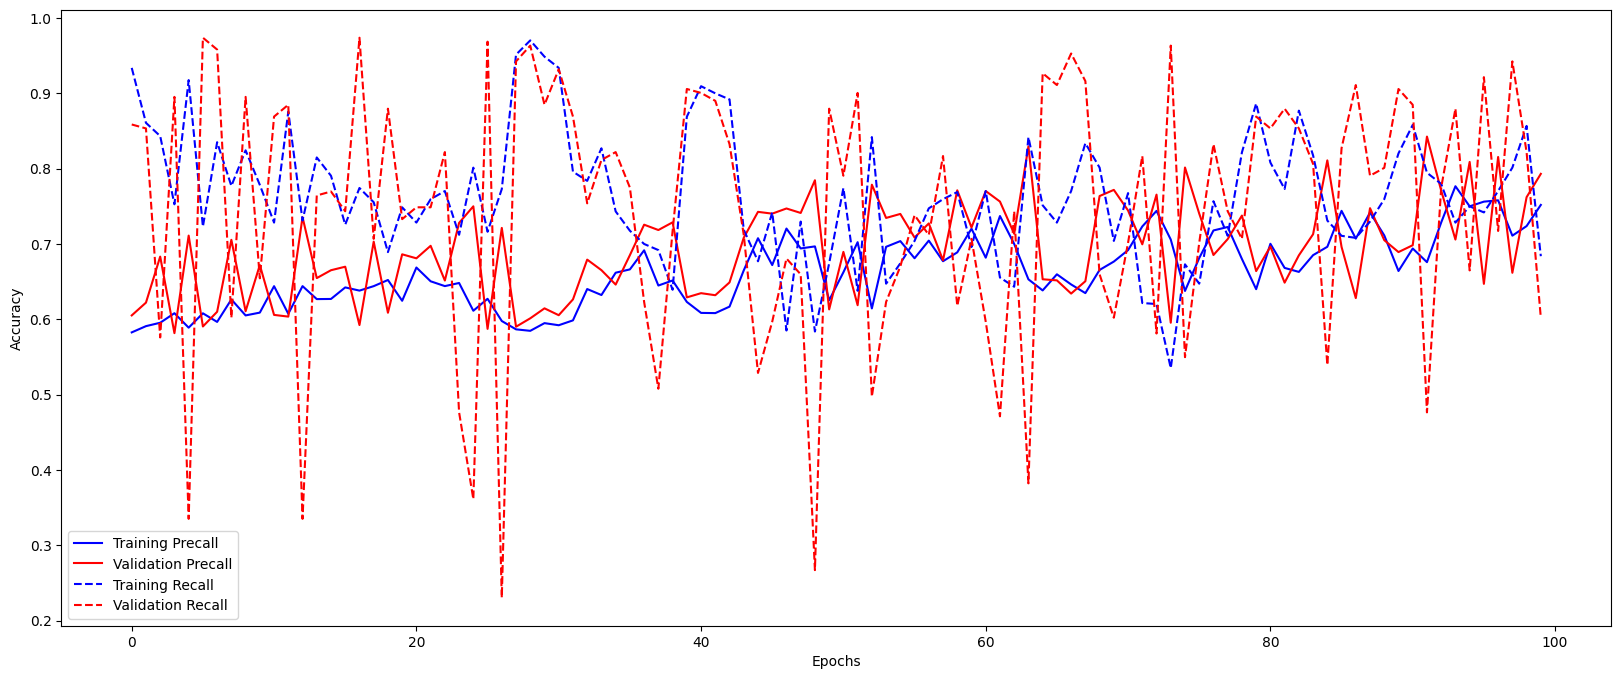

In [236]:
plt.figure(figsize=(20,8))
plt.plot(hist_df.loc[:, ['precision_8']], 'blue', label='Training Precall')
plt.plot(hist_df.loc[:, ['val_precision_8']],'red', label='Validation Precall')
plt.plot(hist_df.loc[:, ['recall_8']], 'b--', label='Training Recall')
plt.plot(hist_df.loc[:, ['val_recall_8']],'r--', label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="best")

plt.show()

## Network Tuning & Experiments

>In this part first we update the model function so we it would be easier to change the model's parameters and inputs and compare the results, so we concatenate create model, compile and fit, into one function named "build_and_train_model".

In [237]:
def build_and_train_model(
    # -------------------- Data --------------------
    X_train=None,
    y_train=None,
    X_test=None,
    y_test=None,
    # -------------------- Architecture & Representation --------------------
    hidden_sizes=[30, 10, 2],
    activations=['sigmoid', 'relu', 'tanh'],
    num_classes=2,
    weight_init='he',
    use_batchnorm=False,
    # -------------------- Training & Optimization --------------------
    optimizer='adam',
    learning_rate=0.01,
    lr_schedule=None,
    batch_size=32,
    epochs=100,
    early_stopping_patience=20,
    early_stopping_min_delta=0.001,
    validation_split=0.2,
    class_weight=None,                   
    # -------------------- Regularization & Stability --------------------
    l1_l2_reg=None,
    activity_reg=None,
    dropout_rates=None,
    gradient_clip_norm=None
):
    if X_train is None or y_train is None:
        raise ValueError("Please provide training data (X_train, y_train).")

    # --- Build model (unchanged) ---
    model = Sequential()
    input_dim = X_train.shape[1]

    if weight_init == 'xavier':
        init = tf.keras.initializers.GlorotUniform()
    elif weight_init == 'he':
        init = tf.keras.initializers.HeNormal()
    elif weight_init == 'random':
        init = tf.keras.initializers.RandomNormal()
    else:
        init = None

    kernel_reg = None
    if l1_l2_reg:
        kernel_reg = regularizers.l1_l2(l1=l1_l2_reg.get('l1', 0.0), l2=l1_l2_reg.get('l2', 0.0))

    for i, (units, act) in enumerate(zip(hidden_sizes, activations)):
        model.add(layers.Dense(units, activation=act, kernel_initializer=init,
                               kernel_regularizer=kernel_reg, activity_regularizer=activity_reg))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        if dropout_rates and i < len(dropout_rates) and dropout_rates[i] > 0:
            model.add(layers.Dropout(dropout_rates[i]))

    if num_classes == 2:
        model.add(layers.Dense(1, activation='sigmoid', kernel_initializer=init))
        loss = 'binary_crossentropy'
    else:
        model.add(layers.Dense(num_classes, activation='softmax', kernel_initializer=init))
        loss = 'sparse_categorical_crossentropy'

    # --- Optimizer ---
    if optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0)
    elif optimizer == 'sgd_momentum':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer}")

    if gradient_clip_norm:
        opt.clipnorm = gradient_clip_norm

    if lr_schedule == 'exponential':
        opt.learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(learning_rate, decay_steps=1000, decay_rate=0.96)
    elif lr_schedule == 'step':
        boundaries = [30, 60]
        values = [learning_rate, learning_rate*0.1, learning_rate*0.01]
        opt.learning_rate = tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries, values)
    elif lr_schedule is not None:
        opt.learning_rate = lr_schedule

    # --- Compile ---
    if num_classes == 2:
        model.compile(loss=loss, optimizer=opt,
                      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    else:
        model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])

    # --- Class weight handling (NEW) ---
    if class_weight == 'auto' and num_classes > 2:
        classes = np.unique(y_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weight = dict(zip(classes, weights))
        print(f"Auto-computed class weights: {class_weight}")
    elif class_weight is not None and not isinstance(class_weight, dict):
        raise ValueError("class_weight must be None, a dict, or the string 'auto'")

    # --- Early stopping ---
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        min_delta=early_stopping_min_delta,
        patience=early_stopping_patience,
        restore_best_weights=True
    )

    # --- Train ---
    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=validation_split,
        callbacks=[early_stop],
        class_weight=class_weight,      
        verbose=1
    )

    # --- Optional test evaluation ---
    if X_test is not None and y_test is not None:
        print("\nFinal evaluation on test set:")
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)[:2]
        print(f"Test accuracy: {test_acc:.4f}")
        if num_classes > 2:
            
            y_pred_probs = model.predict(X_test)
            y_pred = np.argmax(y_pred_probs, axis=1)
            print(classification_report(y_test, y_pred))

    return history, model

1. Compare Optimizers

In [238]:
# Compare optimizers
print("=== Optimizer comparison (3‑class) ===")
for opt in ['sgd', 'sgd_momentum', 'adam']:
      print(f"\nTraining with {opt}")
      history, _ = build_and_train_model(
            X_train, y_train, X_test, y_test,
            optimizer=opt,
            learning_rate=0.01,
            epochs=20,
            hidden_sizes=[64, 32],
            activations=['relu', 'relu']
      )
      print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")

=== Optimizer comparison (3‑class) ===

Training with sgd
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4633 - loss: nan - precision_9: 0.5584 - recall_9: 0.2905 - val_accuracy: 0.4105 - val_loss: nan - val_precision_9: 0.0000e+00 - val_recall_9: 0.0000e+00
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4286 - loss: nan - precision_9: 0.0000e+00 - recall_9: 0.0000e+00 - val_accuracy: 0.4105 - val_loss: nan - val_precision_9: 0.0000e+00 - val_recall_9: 0.0000e+00
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4286 - loss: nan - precision_9: 0.0000e+00 - recall_9: 0.0000e+00 - val_accuracy: 0.4105 - val_loss: nan - val_precision_9: 0.0000e+00 - val_recall_9: 0.0000e+00
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4286 - loss: nan - precision_9: 0.0000e+00 - recall_9: 0.0000e+00 - val_accuracy: 0.4105 - val_loss: nan - val_precision_9: 0.0000e+00 - val_recall_9: 0.0000e+00
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

> As we can see, the type of optimizer we use can greatly change the performance of the model, here sgd has the least accuracy while, sgd_momentum is better and adam optimizer's performance is the best.

2. Learning Rate Variations

In [240]:
# Learning rate variations
print("\n=== Learning rate effects ===")
for lr in [1e-3, 1e-2, 1.0]:
    print(f"\nLR = {lr}")
    history, _ = build_and_train_model(
            X_train, y_train,
            num_classes=3,
            learning_rate=lr,
            epochs=20
    )
    print(f"Final val loss: {history.history['val_loss'][-1]:.4f}")


=== Learning rate effects ===

LR = 0.001
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3228 - loss: 1.4763 - val_accuracy: 0.4228 - val_loss: 1.2044
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5398 - loss: 0.9366 - val_accuracy: 0.6204 - val_loss: 0.7900
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5753 - loss: 0.7630 - val_accuracy: 0.5895 - val_loss: 0.7405
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5753 - loss: 0.7385 - val_accuracy: 0.5895 - val_loss: 0.7303
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5714 - loss: 0.7307 - val_accuracy: 0.5895 - val_loss: 0.7244
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5714 - loss: 0.7260 - val_accuracy: 0.5895 - val_loss: 0.7191
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.7220 - val_accuracy: 0.5895 - val_loss: 0.7159
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5714 - lo

> As we can see by increasing the learning rate, at first the loss decreases, but as we continue increasing, the loss increases again.

3. Learning Rate Scheduling

In [241]:
# Learning rate scheduling
print("\n=== LR scheduling ===")
for schedule in [None, 'exponential', 'step']:
      print(f"\nSchedule = {schedule}")
      history, _ = build_and_train_model(
            X_train, y_train,
            num_classes=3,
            learning_rate=0.01, lr_schedule=schedule, epochs=20
      )
      print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")


=== LR scheduling ===

Schedule = None
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5606 - loss: 0.8226 - val_accuracy: 0.5957 - val_loss: 0.7216
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5660 - loss: 0.7200 - val_accuracy: 0.6019 - val_loss: 0.7141
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5838 - loss: 0.7027 - val_accuracy: 0.5895 - val_loss: 0.6962
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5861 - loss: 0.6948 - val_accuracy: 0.5988 - val_loss: 0.6868
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5815 - loss: 0.6908 - val_accuracy: 0.4167 - val_loss: 0.7372
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5668 - loss: 0.6998 - val_accuracy: 0.5833 - val_loss: 0.6867
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5737 - loss: 0.6903 - val_accuracy: 0.5772 - val_loss: 0.6862
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5807 - loss: 0

> Here we compared 2 types of learning schedulings, step and exponential, as we can see here it didn't change the performance, but generally it helps escape plateaus, improves final accuracy. Allows higher initial LR for speed, then fine-tunes.

4. Batch Size Effects

In [242]:
# Batch size effects
print("\n=== Batch size effects ===")
for bs in [16, 64, 256]:
     print(f"\nBatch size = {bs}")
     history, _ = build_and_train_model(
            X_train, y_train,
            num_classes=3,
            batch_size=bs, epochs=20
     )
     print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")


=== Batch size effects ===

Batch size = 16
Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5560 - loss: 0.8266 - val_accuracy: 0.5833 - val_loss: 0.7022
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5707 - loss: 0.6985 - val_accuracy: 0.5802 - val_loss: 0.6924
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5714 - loss: 0.6917 - val_accuracy: 0.5741 - val_loss: 0.6863
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5730 - loss: 0.6896 - val_accuracy: 0.5895 - val_loss: 0.6789
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5699 - loss: 0.6873 - val_accuracy: 0.5895 - val_loss: 0.6801
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5707 - loss: 0.6873 - val_accuracy: 0.5895 - val_loss: 0.6794
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5598 - loss: 0.6854 - val_accuracy: 0.5864 - val_loss: 0.6889
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5622 - lo

> Here we compared 3 different batch sizes, 64, 128 and 256, from 64 to 128 the accuracy increased but from 128 to 256 it didn't change.


I changed these 2 effects mutiple times during this code so I only wrote the results.

>Early stopping:	Prevents overfitting by halting when validation loss stops improving. Essential for non-regularized or deep models.

>Number of epochs: Too few → underfitting (high bias).
                  Too many → overfitting (high variance) unless regularization/early stopping is used.



5. Depth & Width 

In [244]:
# 5. Depth & Width (architecture)
print("\n=== Depth & width ===")
architectures = [
        ([10], ['relu']),                 # shallow, narrow
        ([100, 50], ['relu', 'relu']),    # medium, wide
        ([30, 20, 10, 5], ['relu'] * 4)   # deep
    ]
for sizes, acts in architectures:
      print(f"\nHidden layers: {sizes}")
      history, _ = build_and_train_model(
            X_train, y_train,
            num_classes=3,
            hidden_sizes=sizes, activations=acts, epochs=20
      )
      print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")


=== Depth & width ===

Hidden layers: [10]
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5197 - loss: 67.9167 - val_accuracy: 0.4444 - val_loss: 21.0916
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5498 - loss: 13.8342 - val_accuracy: 0.4259 - val_loss: 36.6400
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5436 - loss: 14.9640 - val_accuracy: 0.6883 - val_loss: 3.2619
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6293 - loss: 5.7211 - val_accuracy: 0.8364 - val_loss: 0.8394
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6703 - loss: 4.9001 - val_accuracy: 0.8241 - val_loss: 0.9282
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5876 - loss: 11.1954 - val_accuracy: 0.4537 - val_loss: 14.8629
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6595 - loss: 6.3009 - val_accuracy: 0.7099 - val_loss: 3.7338
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.644

> In this part as I increased the number of layers, the accuracy decreased.

>Generally, Depth (more hidden layers), Can learn hierarchical features → higher representational power. But harder to train (vanishing/exploding gradients). May overfit if data is small.
Width (neurons per layer), Wider layers capture more interactions per level. Increasing width adds capacity faster than depth (more parameters). Diminishing returns after a point.

6. Activation Functions

In [245]:
# Activation functions (ensure the last hidden layer’s activation doesn’t conflict with output softmax)
print("\n=== Activation functions ===")
for act in ['relu', 'leaky_relu', 'tanh', 'sigmoid']:
    print(f"\nActivation = {act}")
    history, _ = build_and_train_model(
            X_train, y_train,
            num_classes=3,
            hidden_sizes=[64, 32],
            activations=[act, act],
            epochs=20
    )
    print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")



=== Activation functions ===

Activation = relu
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5398 - loss: 149.1163 - val_accuracy: 0.5741 - val_loss: 52.6290
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5459 - loss: 33.1821 - val_accuracy: 0.5926 - val_loss: 4.6986
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5822 - loss: 8.8163 - val_accuracy: 0.4753 - val_loss: 17.6524
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5707 - loss: 14.2742 - val_accuracy: 0.4722 - val_loss: 18.3265
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6108 - loss: 11.5556 - val_accuracy: 0.5401 - val_loss: 9.3084
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5892 - loss: 7.4269 - val_accuracy: 0.6420 - val_loss: 4.1600
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6749 - loss: 3.3938 - val_accuracy: 0.6019 - val_loss: 7.4126
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy

> Here we compare different activation functions, as we can see leaky_relu outperforms other models, but it seems a little bit overfitting had happened.

> Generally, ReLU, avoids vanishing gradient, cheap. Risk of dead neurons (negative side).
LeakyReLU, fixes dead neurons, small negative slope → often slightly better than ReLU.
Tanh, zero-centered, good for some problems. Saturates for large inputs → vanishing gradient in deep nets.
Sigmoid, avoid except output layer. Saturates → very slow learning in deep networks.

7. Weight Initialization

In [246]:
# Weight initialization
print("\n=== Weight initialization ===")
for init in ['xavier', 'he', 'random']:
    print(f"\nInit = {init}")
    history, _ = build_and_train_model(
            X_train, y_train,
            num_classes=3,
            weight_init=init, epochs=20
    )
    print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")


=== Weight initialization ===

Init = xavier
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5243 - loss: 0.7744 - val_accuracy: 0.5895 - val_loss: 0.7132
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.7089 - val_accuracy: 0.5895 - val_loss: 0.6960
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6987 - val_accuracy: 0.5895 - val_loss: 0.6915
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6950 - val_accuracy: 0.5895 - val_loss: 0.6848
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6896 - val_accuracy: 0.5895 - val_loss: 0.6828
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6882 - val_accuracy: 0.5895 - val_loss: 0.6815
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6876 - val_accuracy: 0.5895 - val_loss: 0.6829
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - 

> Here we compared different weight initializations, but they didn't change much the model's performance.

8. Batch Normalization

In [247]:
 # Batch normalization
 print("\n=== Batch Normalization ===")
 for bn in [False, True]:
      print(f"\nBatchNorm = {bn}")
      history, _ = build_and_train_model(
            X_train, y_train,
            num_classes=3,
            use_batchnorm=bn, epochs=20
      )
      print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")


=== Batch Normalization ===

BatchNorm = False
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5467 - loss: 0.7930 - val_accuracy: 0.5895 - val_loss: 0.7087
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5768 - loss: 0.7069 - val_accuracy: 0.6296 - val_loss: 0.6834
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5931 - loss: 0.6944 - val_accuracy: 0.5833 - val_loss: 0.6905
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5938 - loss: 0.6878 - val_accuracy: 0.5772 - val_loss: 0.6736
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5900 - loss: 0.6761 - val_accuracy: 0.4198 - val_loss: 0.7061
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5730 - loss: 0.6884 - val_accuracy: 0.6265 - val_loss: 0.6648
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5575 - loss: 0.6803 - val_accuracy: 0.5926 - val_loss: 0.6809
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5676 

> We can see that batch normalisation improves slightly the accuracy.

>Generally, it stabilizes training, allows higher LR, reduces sensitivity to initialization. Also acts as weak regularizer. Especially helpful for deeper networks.

9. L1/L2 Weight Regularization

In [248]:
# L1/L2 weight regularization
print("\n=== L1/L2 weight regularization ===")
reg_configs = [None, {'l2': 0.001}, {'l1': 0.001, 'l2': 0.001}]
for reg in reg_configs:
    print(f"\nL1/L2 = {reg}")
    history, _ = build_and_train_model(
      X_train, y_train,
      num_classes=3,
      l1_l2_reg=reg, epochs=20
    )
    print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")


=== L1/L2 weight regularization ===

L1/L2 = None
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5514 - loss: 0.8528 - val_accuracy: 0.5895 - val_loss: 0.7367
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5714 - loss: 0.7225 - val_accuracy: 0.5895 - val_loss: 0.7049
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.7038 - val_accuracy: 0.5895 - val_loss: 0.6930
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6972 - val_accuracy: 0.5895 - val_loss: 0.6897
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6928 - val_accuracy: 0.5895 - val_loss: 0.6922
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6925 - val_accuracy: 0.5895 - val_loss: 0.6840
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.6897 - val_accuracy: 0.5895 - val_loss: 0.6843
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.571

> We can see that weight regularization, didn't change much the accuracy.

10. Activity Regularization

In [249]:
# Activity regularization
print("\n=== Activity regularization ===")
act_reg = regularizers.l1(0.001)
history, _ = build_and_train_model(
        X_train, y_train,
        num_classes=3,
        activity_reg=act_reg, epochs=20
)
print(f"With activity L1(0.001) val acc: {history.history['val_accuracy'][-1]:.4f}")


=== Activity regularization ===
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5645 - loss: 1.3907 - val_accuracy: 0.5957 - val_loss: 1.2570
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 1.2280 - val_accuracy: 0.5895 - val_loss: 1.1931
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 1.1722 - val_accuracy: 0.5895 - val_loss: 1.1337
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 1.1400 - val_accuracy: 0.5895 - val_loss: 1.1282
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5714 - loss: 1.1334 - val_accuracy: 0.5895 - val_loss: 1.1217
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5714 - loss: 1.1047 - val_accuracy: 0.5895 - val_loss: 1.0828
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5714 - loss: 1.0547 - val_accuracy: 0.5895 - val_loss: 1.0245
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5714 - loss: 1.0

>Activity regularization also didn't change the performance.

>Generally, it penalizes large hidden activations → encourages compact internal representations. Less common than weight decay.

11. Dropout

In [250]:
# Dropout
print("\n=== Dropout ===")
dropout_options = [None, [0.2, 0.5], [0.5, 0.5]]
for dr in dropout_options:
     print(f"\nDropout rates = {dr}")
     history, _ = build_and_train_model(
        X_train, y_train,
        num_classes=3,
        hidden_sizes=[64, 32],
        activations=['relu', 'relu'],
        dropout_rates=dr, epochs=20
     )
     print(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}")


=== Dropout ===

Dropout rates = None
Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5282 - loss: 208.2667 - val_accuracy: 0.5926 - val_loss: 72.4557
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5606 - loss: 34.1089 - val_accuracy: 0.6667 - val_loss: 9.3905
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5807 - loss: 20.4410 - val_accuracy: 0.6759 - val_loss: 6.0043
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5830 - loss: 24.9114 - val_accuracy: 0.7130 - val_loss: 3.7072
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5722 - loss: 18.5361 - val_accuracy: 0.4660 - val_loss: 28.5488
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5506 - loss: 32.4991 - val_accuracy: 0.6111 - val_loss: 40.0017
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5869 - loss: 18.2527 - val_accuracy: 0.7006 - val_loss: 5.3961
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.661

> We can see that dropout decreases the accuracy 

>Generally, it randomly drops neurons during training → prevents co-adaptation. Very effective against overfitting. Typically set 0.2–0.5 on hidden layers.

## Regression

In [112]:
df_regression = df.copy()

In [113]:
# Set target variable 
target_variable = df_regression.pop('Sleep_Hours')

In [114]:
y = target_variable

In [115]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df_regression, y, test_size=0.3)
print(X_train.shape)
print(X_test.shape)

(7000, 14)
(3000, 14)


In [116]:
# Create model
model = Sequential()

# Add a layer with 30 hidden neurons
model.add(Dense(30, input_dim=X_train.shape[1], activation='sigmoid'))

# Add a layer with 10 hidden neurons
model.add(Dense(10, activation='relu'))

# Add a layer with 2 hidden neurons
model.add(Dense(3, activation='tanh'))

# Add the output layer, with sigmoid activation fuction (to predict the rain)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [117]:

model.compile(
    optimizer='adam',
    loss='mse',           # Mean Squared Error
    metrics=['mae']       # Mean Absolute Error to monitor
)


In [118]:

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # Uses 20% of training data for validation
    verbose=1
)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0279 - mae: 0.1334 - val_loss: 0.0239 - val_mae: 0.1256
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0142 - mae: 0.0938 - val_loss: 0.0097 - val_mae: 0.0762
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0080 - mae: 0.0708 - val_loss: 0.0082 - val_mae: 0.0710
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0073 - mae: 0.0689 - val_loss: 0.0077 - val_mae: 0.0703
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - mae: 0.0665 - val_loss: 0.0072 - val_mae: 0.0662
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - mae: 0.0646 - val_loss: 0.0078 - val_mae: 0.0719
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0061 - mae: 0.0630 - val_loss: 0.0064 - val_mae: 0.0643
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0058 - mae: 0.0612 - val_loss: 0.0060 - val_mae: 0.0610
Epoch 9/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [119]:

# Evaluate on test set
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.4f}")

# Make predictions
predictions = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0050 - mae: 0.0579
Test MAE: 0.0579
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


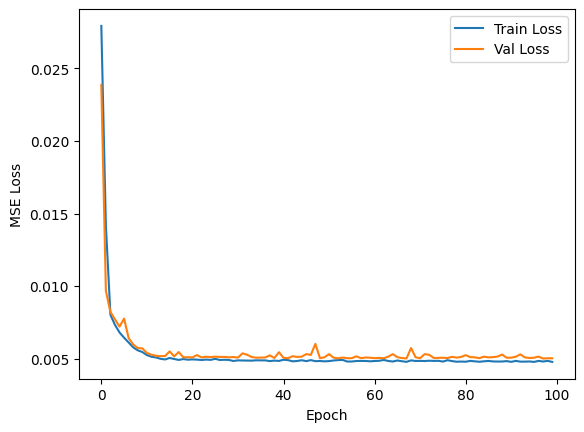

In [120]:
# Trainig Visualisation
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

## 1. Why are neural networks so powerful?

Neural networks derive their power from several key properties:

1. **Universal approximation capability** – A sufficiently large neural network can approximate any continuous function to arbitrary accuracy (Universal Approximation Theorem). This means they are theoretically capable of modeling any pattern.

2. **Automatic feature learning** – Unlike traditional machine learning models that require hand-crafted features, neural networks learn hierarchical representations directly from raw data. Lower layers detect simple patterns (edges, textures), while higher layers combine them into abstract concepts (objects, faces).

3. **Distributed representations** – Information is spread across many neurons and weights, making the network robust to noise and capable of capturing complex interactions between features.

4. **Non‑linearity** – Activation functions (ReLU, sigmoid, tanh) introduce non‑linear transformations, enabling the network to model complex, non‑linear relationships that linear models cannot.

5. **Scalability** – Neural networks perform exceptionally well when provided with large amounts of data, modern GPUs, and optimised architectures (e.g., CNNs, RNNs, Transformers). Their performance often continues to improve with more data.

6. **End‑to‑end learning** – They can be trained to directly optimise a final objective (e.g., classification loss) without needing separate stages for feature extraction and modelling.

In essence, neural networks are powerful because they combine **flexible function approximation**, **automatic hierarchical representation learning**, and the ability to **scale with data and compute**.

---

## 2. Why does training become more difficult as we go deeper?

Adding more hidden layers (increasing depth) introduces several optimisation and stability challenges:

- **Vanishing / exploding gradients** – Gradients are propagated back through many layers using the chain rule. In deep networks, gradients can shrink exponentially (vanish) or grow exponentially (explode). This causes early layers to learn very slowly (or not at all) and can lead to numerical instability.

- **Degradation problem** – Deeper networks sometimes exhibit **higher training error** than their shallower counterparts, even though the deeper network should theoretically be able to mimic the shallower one (by learning identity mappings). This observation led to the development of ResNets.

- **Shattered gradients** – In very deep networks, gradients can become decorrelated and resemble random noise, hindering effective learning.

- **Increased non‑linearity** – Each layer adds more non‑linear composition, making the optimisation landscape more rugged, with many local minima and saddle points.

- **Higher sensitivity to initialisation** – Poor weight initialisation can magnify the vanishing/exploding gradient problem. Techniques like He or Xavier initialisation help but do not fully solve the issue for extremely deep networks.

- **Loss of information** – As signals pass through many non‑linear transformations, useful information about the input can be lost (information bottleneck perspective).

**Mitigations** include residual connections (skip connections), batch normalisation, careful choice of activation functions (e.g., ReLU variants), gradient clipping, and normalised initialisation.

---

## 3. If MLPs can approximate any function with a single hidden layer, what unique benefits does depth provide that cannot be achieved simply by increasing width?

Although a single hidden layer is theoretically sufficient to approximate any continuous function, the number of neurons required may be **exponentially large**. Depth offers several irreplaceable advantages:

| Benefit | Explanation |
|---------|-------------|
| **Parameter efficiency** | Some functions require an **exponential number of neurons** to approximate with a shallow (single‑layer) network, but only a **polynomial number** with a deep network. Example: the parity function on `n` inputs needs `O(2ⁿ)` neurons in a shallow network, but `O(n²)` in a deep one. |
| **Hierarchical feature reuse** | Deep networks naturally learn a **compositional hierarchy**: low‑level features (edges → parts → objects → scenes). To replicate this with a wide shallow net, you would need to pre‑engineer all such hierarchical combinations – which is impractical. |
| **Inductive bias** | Depth encodes a prior that the world is **hierarchical** and compositional. This bias leads to better generalisation on tasks like image recognition, speech, and language, whereas a wide shallow network has no such built‑in structure. |
| **Parameter sharing across layers** | Deep networks can reuse features learned at one level across many higher levels. In a wide shallow net, each output feature is an independent combination of all inputs – no reuse. |
| **Exponential representational capacity** | Deep networks can represent certain functions (e.g., nested sums of products) using far fewer parameters. The **expressive efficiency** grows exponentially with depth – you can achieve the same approximation quality with exponentially fewer parameters than a shallow network. |
| **Training dynamics** | For very complex functions, a **moderately deep** network with residual connections can be **easier** to train than an extremely wide shallow network that requires millions of neurons and massive amounts of data to avoid overfitting. |

